In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
N_TRIALS = 10000
BANDITS = [0.2, 0.5, 0.75]  # The true probabilities of winning for each bandit

In [29]:
class Bandit:
    def __init__(self, p):
        self.p = p              # The true probability of winning for this bandit
        self.p_estimate = 10   # The estimated probability of winning for this bandit
        self.N = 0              # Number of samples collected from this bandit so far
    
    def pull(self):
        # Create a random number between 0 and 1. If the number is less than p, return 1 (reward), else return 0 (no reward)
        return 1 if np.random.random() < self.p else 0
    
    def update(self, x):
        # Update the number of samples and the estimated probability of winning for this bandit
        self.N += 1
        self.p_estimate = ((self.N - 1)*self.p_estimate + x) / self.N



In [30]:
# Generate the bandits with the specified probabilities
bandits             = [Bandit(p) for p in BANDITS]
n_times_optimal     = 0
rewards             = []

# Run the simulation for N_TRIALS
for trial_indx in np.arange(N_TRIALS):
    # 1] Exploit: select the bandit with the highest estimated probability of winning
    bandit_indx = np.argmax([b.p_estimate for b in bandits])

    # 2] Pull the selected bandit and get the reward
    reward = bandits[bandit_indx].pull()
    rewards.append(reward)

    # 3] Update the selected bandit with the received reward
    bandits[bandit_indx].update(reward)

    # 4] Check if the selected bandit is the optimal one (the one with the highest true probability of winning)
    if bandit_indx == np.argmax(BANDITS):
        n_times_optimal += 1


In [31]:
# Print the p_estimate for each bandit, the number of times each bandit was selected and the total reward
for bandit_indx, bandit in enumerate(bandits):
    print(f"Bandit {bandit_indx}: p_estimate = {bandit.p_estimate:.3f}, true p = {bandit.p:.3f}, N = {bandit.N}, N_trials = {N_TRIALS}")

print(80*"=")
print(f"The number of times the optimal bandit was selected = {n_times_optimal}")
print(f"The total reward = {np.sum(rewards)}")
print(f"The win rate = {np.sum(rewards)/N_TRIALS:.3f}")

Bandit 0: p_estimate = 0.000, true p = 0.200, N = 1, N_trials = 10000
Bandit 1: p_estimate = 0.000, true p = 0.500, N = 1, N_trials = 10000
Bandit 2: p_estimate = 0.757, true p = 0.750, N = 9998, N_trials = 10000
The number of times the optimal bandit was selected = 9998
The total reward = 7571
The win rate = 0.757


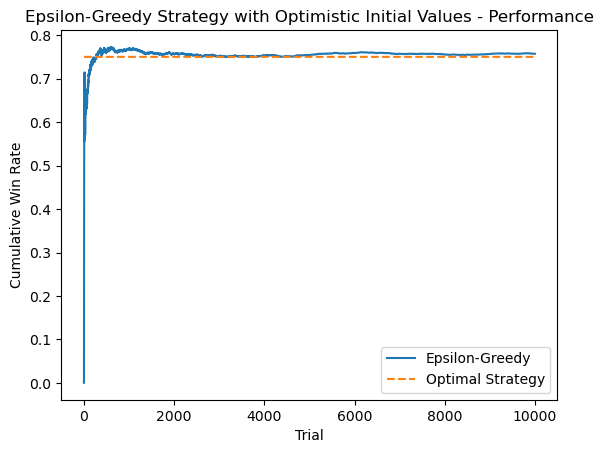

In [32]:
# Plotting the comulative results 
comulative_rewards = np.cumsum(rewards)
cumulative_win_rate = comulative_rewards / (np.arange(N_TRIALS) + 1)
plt.plot(cumulative_win_rate, label="Epsilon-Greedy")
plt.plot(np.ones(N_TRIALS)*np.max(BANDITS), label="Optimal Strategy", linestyle="--")
plt.xlabel("Trial")
plt.ylabel("Cumulative Win Rate")
plt.title("Epsilon-Greedy Strategy with Optimistic Initial Values - Performance")
plt.legend()